# Exploratory Data Analysis and Feature Engineering

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
pd.__version__

'2.3.3'

In [4]:
pd.set_option('mode.copy_on_write', True)

In [5]:
df_players_stats = pd.read_csv('../data/raw/PlayerStatistics.csv')
df_players_stats.head(5)

/tmp/ipykernel_30458/308571118.py:1: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_players_stats = pd.read_csv('../data/raw/PlayerStatistics.csv')


,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,...,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints
0,Svi,Mykhailiuk,1629004,22500363,2025-12-07 15:00:00,Utah,Jazz,Oklahoma City,Thunder,NaN,...,0.667,0.0,0.0,0.00,2.0,0.0,2.0,1.0,3.0,-13.0
1,Kenrich,Williams,1629026,22500363,2025-12-07 15:00:00,Oklahoma City,Thunder,Utah,Jazz,NaN,...,0.667,4.0,1.0,0.25,5.0,2.0,7.0,3.0,2.0,29.0
2,Isaiah,Joe,1630198,22500363,2025-12-07 15:00:00,Oklahoma City,Thunder,Utah,Jazz,NaN,...,0.000,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0
3,Aaron,Wiggins,1630598,22500363,2025-12-07 15:00:00,Oklahoma City,Thunder,Utah,Jazz,NaN,...,0.833,2.0,2.0,1.00,3.0,0.0,3.0,3.0,2.0,9.0
4,Chet,Holmgren,1631096,22500363,2025-12-07 15:00:00,Oklahoma City,Thunder,Utah,Jazz,NaN,...,0.500,3.0,0.0,0.00,8.0,1.0,9.0,2.0,3.0,16.0


In [6]:
df_players_stats.sample(5)

,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,...,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints
179112,Sekou,Doumbouya,1629635,22000481,2021-02-23 19:00:00,Detroit,Pistons,Orlando,Magic,Regular Season,...,0.00,0.0,0.0,0.000,2.0,0.0,2.0,2.0,0.0,-1.0
437888,Kemba,Walker,202689,21300136,2013-11-16 19:00:00,Charlotte,Bobcats,Miami,Heat,Regular Season,...,0.60,6.0,5.0,0.833,3.0,0.0,3.0,1.0,1.0,-15.0
780729,Jamaal,Tinsley,2224,20201119,2003-04-08 20:30:00,Indiana,Pacers,Chicago,Bulls,Regular Season,...,0.25,0.0,0.0,0.000,2.0,0.0,2.0,4.0,6.0,-9.0
397369,Alexis,Ajinca,201582,21400258,2014-12-02 20:00:00,New Orleans,Pelicans,Oklahoma City,Thunder,Regular Season,...,0.00,2.0,2.0,1.000,0.0,0.0,0.0,3.0,0.0,-10.0
1510315,Don,Kojis,77295,26800458,1969-02-22 19:00:00,San Diego,Rockets,New York,Knicks,Regular Season,...,0.00,9.0,8.0,0.889,0.0,0.0,12.0,4.0,0.0,0.0


In [7]:
df_players_stats.shape

(1639236, 35)

In [8]:
#display all columns on screen
pd.set_option('display.max_columns', 36)

In [9]:
df_players_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639236 entries, 0 to 1639235
Data columns (total 35 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   firstName                1639236 non-null  object 
 1   lastName                 1639236 non-null  object 
 2   personId                 1639236 non-null  int64  
 3   gameId                   1639236 non-null  int64  
 4   gameDateTimeEst          1639236 non-null  object 
 5   playerteamCity           1639236 non-null  object 
 6   playerteamName           1639236 non-null  object 
 7   opponentteamCity         1639236 non-null  object 
 8   opponentteamName         1639236 non-null  object 
 9   gameType                 1629175 non-null  object 
 10  gameLabel                94707 non-null    object 
 11  gameSubLabel             6166 non-null     object 
 12  seriesGameNumber         135048 non-null   float64
 13  win                      1639236 non-null 

In [10]:
df_players_stats.columns

Index(['firstName', 'lastName', 'personId', 'gameId', 'gameDateTimeEst',
       'playerteamCity', 'playerteamName', 'opponentteamCity',
       'opponentteamName', 'gameType', 'gameLabel', 'gameSubLabel',
       'seriesGameNumber', 'win', 'home', 'numMinutes', 'points', 'assists',
       'blocks', 'steals', 'fieldGoalsAttempted', 'fieldGoalsMade',
       'fieldGoalsPercentage', 'threePointersAttempted', 'threePointersMade',
       'threePointersPercentage', 'freeThrowsAttempted', 'freeThrowsMade',
       'freeThrowsPercentage', 'reboundsDefensive', 'reboundsOffensive',
       'reboundsTotal', 'foulsPersonal', 'turnovers', 'plusMinusPoints'],
      dtype='object')

In [11]:
df_players_stats.describe()

,personId,gameId,seriesGameNumber,win,home,numMinutes,points,assists,blocks,steals,fieldGoalsAttempted,fieldGoalsMade,fieldGoalsPercentage,threePointersAttempted,threePointersMade,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints
count,1.639236e+06,1.639236e+06,135048.000000,1.639236e+06,1.639236e+06,1.475688e+06,1.638017e+06,1.638017e+06,1.638017e+06,1.638017e+06,1.638017e+06,1.638017e+06,1.638017e+06,1.638017e+06,1.638017e+06,1.638017e+06,1.638017e+06,1.638017e+06,1.638017e+06,1.638017e+06,1.638017e+06,1.638017e+06,1.638017e+06,1.638017e+06,1.638017e+06
mean,2.861187e+05,2.538129e+07,2.388506,4.996687e-01,5.005289e-01,2.178115e+01,9.190823e+00,1.959516e+00,3.684541e-01,5.830519e-01,7.315590e+00,3.489772e+00,3.653756e-01,1.215876e+00,4.295334e-01,1.161199e-01,2.365304e+00,1.781739e+00,4.222889e-01,2.174496e+00,8.521731e-01,3.773719e+00,1.974803e+00,1.033947e+00,-7.753277e-05
std,4.766459e+06,6.511647e+06,2.040620,5.000000e-01,4.999999e-01,1.276893e+01,8.520923e+00,2.544617e+00,8.324685e-01,9.595001e-01,6.356821e+00,3.308624e+00,2.717313e-01,2.166663e+00,9.814933e-01,2.457851e-01,3.051162e+00,2.450406e+00,4.254177e-01,2.676366e+00,1.386995e+00,3.934780e+00,1.655295e+00,1.402990e+00,7.409261e+00
min,2.000000e+00,1.030000e+07,0.000000,0.000000e+00,0.000000e+00,-5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-5.800000e+01
25%,1.739000e+03,2.120027e+07,0.000000,0.000000e+00,0.000000e+00,1.200000e+01,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,7.708900e+04,2.500007e+07,2.000000,0.000000e+00,1.000000e+00,2.200000e+01,7.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00,3.000000e+00,4.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,3.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00
75%,2.016110e+05,2.860058e+07,4.000000,1.000000e+00,1.000000e+00,3.200000e+01,1.400000e+01,3.000000e+00,0.000000e+00,1.000000e+00,1.100000e+01,5.000000e+00,5.380000e-01,2.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,3.000000e+00,8.560000e-01,3.000000e+00,1.000000e+00,6.000000e+00,3.000000e+00,2.000000e+00,0.000000e+00
max,1.962938e+09,6.240000e+07,7.000000,1.000000e+00,1.000000e+00,9.600000e+01,1.000000e+02,3.000000e+01,1.700000e+01,1.100000e+01,6.300000e+01,3.600000e+01,9.000000e+00,2.400000e+01,1.400000e+01,1.000000e+00,3.900000e+01,3.000000e+01,1.100000e+01,2.900000e+01,2.100000e+01,5.500000e+01,2.300000e+01,1.400000e+01,5.700000e+01


In [12]:
df_players_stats['gameType'].unique()

array([nan, 'in-season', 'Global Games', 'Playoffs', 'Play-in Tournament',
       'Regular Season', 'Preseason', 'NBA Cup', 'NBA Emirates Cup'],
      dtype=object)

In [13]:
df_players_stats['points'].value_counts()


points
0.0      322325
2.0      127123
4.0      101191
6.0       91717
8.0       80666
          ...  
69.0          1
66.0          1
72.0          1
100.0         1
78.0          1
Name: count, Length: 77, dtype: int64

In [14]:
df_players_stats.dtypes

firstName                   object
lastName                    object
personId                     int64
gameId                       int64
gameDateTimeEst             object
playerteamCity              object
playerteamName              object
opponentteamCity            object
opponentteamName            object
gameType                    object
gameLabel                   object
gameSubLabel                object
seriesGameNumber           float64
win                          int64
home                         int64
numMinutes                 float64
points                     float64
assists                    float64
blocks                     float64
steals                     float64
fieldGoalsAttempted        float64
fieldGoalsMade             float64
fieldGoalsPercentage       float64
threePointersAttempted     float64
threePointersMade          float64
threePointersPercentage    float64
freeThrowsAttempted        float64
freeThrowsMade             float64
freeThrowsPercentage

In [15]:
df_players_stats['gameType'].value_counts()

gameType
Regular Season        1470402
Playoffs                99840
Preseason               54580
NBA Emirates Cup         1759
in-season                1560
Play-in Tournament        829
Global Games              177
NBA Cup                    28
Name: count, dtype: int64

In [16]:
df_players_stats['home'].value_counts(dropna=False)


home
1    820485
0    818751
Name: count, dtype: int64

In [17]:
df_players_stats['win'].value_counts(dropna=False)

win
0    820161
1    819075
Name: count, dtype: int64

In [18]:
df_players_stats[['numMinutes', 'points', 'assists', 'reboundsTotal']].describe()

,numMinutes,points,assists,reboundsTotal
count,1.475688e+06,1.638017e+06,1.638017e+06,1.638017e+06
mean,2.178115e+01,9.190823e+00,1.959516e+00,3.773719e+00
std,1.276893e+01,8.520923e+00,2.544617e+00,3.934780e+00
min,-5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.200000e+01,2.000000e+00,0.000000e+00,1.000000e+00
50%,2.200000e+01,7.000000e+00,1.000000e+00,3.000000e+00
75%,3.200000e+01,1.400000e+01,3.000000e+00,6.000000e+00
max,9.600000e+01,1.000000e+02,3.000000e+01,5.500000e+01


In [19]:
df_players_stats['numMinutes'].isna().sum()

np.int64(163548)

In [20]:
# fraction missing
df_players_stats['numMinutes'].isna().mean()

np.float64(0.09977086886818005)

In [21]:
#check players that has stats but numMinutes = 0
stats_cols = ['points', 'assists', 'reboundsTotal', 'blocks', 'steals']

nan_min_players = df_players_stats.loc[
  (df_players_stats['numMinutes'] == 0) &
  (df_players_stats[stats_cols].sum(axis=1) > 0)
]
nan_min_players.head()

,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,gameLabel,gameSubLabel,seriesGameNumber,win,home,numMinutes,points,assists,blocks,steals,fieldGoalsAttempted,fieldGoalsMade,fieldGoalsPercentage,threePointersAttempted,threePointersMade,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints
21233,Tony,Bradley,1628396,22400942,2025-03-11 19:30:00,Indiana,Pacers,Milwaukee,Bucks,Regular Season,NaN,NaN,0.0,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
49501,Ron,Harper Jr.,1631199,12400001,2024-10-04 12:00:00,Boston,Celtics,Denver,Nuggets,Preseason,Preseason,NaN,0.0,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
49531,Svi,Mykhailiuk,1629004,42300405,2024-06-17 20:30:00,Boston,Celtics,Dallas,Mavericks,Playoffs,NBA Finals,NaN,5.0,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
49908,Jalen,Smith,1630188,42300301,2024-05-21 20:00:00,Indiana,Pacers,Boston,Celtics,Playoffs,East - Conf. Finals,NaN,1.0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-2.0
50072,A.J.,Lawson,1630639,42300225,2024-05-15 21:30:00,Dallas,Mavericks,Oklahoma City,Thunder,Playoffs,West - Conf. Semifinals,NaN,5.0,1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
#check the real dnp players
dnp_players = df_players_stats.loc[
  (df_players_stats['numMinutes'] == 0) &
  (df_players_stats[stats_cols].sum(axis=1) == 0)
  ]

dnp_players.head()

,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,gameLabel,gameSubLabel,seriesGameNumber,win,home,numMinutes,points,assists,blocks,steals,fieldGoalsAttempted,fieldGoalsMade,fieldGoalsPercentage,threePointersAttempted,threePointersMade,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints
6566,Dorian,Finney-Smith,1627827,22500160,2025-11-03 20:00:00-05:00,Houston,Rockets,Dallas,Mavericks,NaN,NaN,NaN,NaN,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6567,Fred,VanVleet,1627832,22500160,2025-11-03 20:00:00-05:00,Houston,Rockets,Dallas,Mavericks,NaN,NaN,NaN,NaN,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6568,JD,Davison,1631120,22500160,2025-11-03 20:00:00-05:00,Houston,Rockets,Dallas,Mavericks,NaN,NaN,NaN,NaN,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6569,Dereck,Lively II,1641726,22500160,2025-11-03 20:00:00-05:00,Dallas,Mavericks,Houston,Rockets,NaN,NaN,NaN,NaN,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6570,Isaiah,Crawford,1642384,22500160,2025-11-03 20:00:00-05:00,Houston,Rockets,Dallas,Mavericks,NaN,NaN,NaN,NaN,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
#add flag where for the nan_min_players
df_players_stats['numMinutes_missing'] = (
  (df_players_stats['numMinutes'] == 0) &
  (df_players_stats[stats_cols].sum(axis=1) > 0)).astype(int)

nan_min_players_check = df_players_stats.loc[
  df_players_stats['numMinutes_missing'] == 1
]
nan_min_players_check.head(10)


,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,gameLabel,gameSubLabel,seriesGameNumber,win,home,numMinutes,points,assists,blocks,steals,fieldGoalsAttempted,fieldGoalsMade,fieldGoalsPercentage,threePointersAttempted,threePointersMade,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints,numMinutes_missing
21233,Tony,Bradley,1628396,22400942,2025-03-11 19:30:00,Indiana,Pacers,Milwaukee,Bucks,Regular Season,NaN,NaN,0.0,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1
49501,Ron,Harper Jr.,1631199,12400001,2024-10-04 12:00:00,Boston,Celtics,Denver,Nuggets,Preseason,Preseason,NaN,0.0,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,1
49531,Svi,Mykhailiuk,1629004,42300405,2024-06-17 20:30:00,Boston,Celtics,Dallas,Mavericks,Playoffs,NBA Finals,NaN,5.0,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1
49908,Jalen,Smith,1630188,42300301,2024-05-21 20:00:00,Indiana,Pacers,Boston,Celtics,Playoffs,East - Conf. Finals,NaN,1.0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-2.0,1
50072,A.J.,Lawson,1630639,42300225,2024-05-15 21:30:00,Dallas,Mavericks,Oklahoma City,Thunder,Playoffs,West - Conf. Semifinals,NaN,5.0,1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
52940,Hunter,Tyson,1641816,22301164,2024-04-10 22:00:00,Denver,Nuggets,Minnesota,Timberwolves,Regular Season,NaN,NaN,NaN,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,1
53272,Nate,Hinton,1630207,22301150,2024-04-09 20:00:00,Houston,Rockets,Orlando,Magic,Regular Season,NaN,NaN,NaN,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,1
53350,Mike,Muscala,203488,22301153,2024-04-09 20:00:00,Oklahoma City,Thunder,Sacramento,Kings,Regular Season,NaN,NaN,NaN,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1
53684,Jaden,Springer,1630531,22301134,2024-04-07 18:00:00,Boston,Celtics,Portland,Trail Blazers,Regular Season,NaN,NaN,NaN,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1
53807,Nate,Hinton,1630207,22301131,2024-04-07 15:30:00,Houston,Rockets,Dallas,Mavericks,Regular Season,NaN,NaN,NaN,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,0.0,0.0,0.0,1


In [24]:
#sort by player and game date
df_players_stats = df_players_stats.sort_values(
    ["personId", "gameDateTimeEst"]
).copy()

#original minutes from the dataframe
clean_minutes = df_players_stats['numMinutes'].copy()

mask = df_players_stats['numMinutes_missing'] == 1
clean_minutes.loc[mask] = np.nan

rolling_minutes = (
    df_players_stats.assign(clean_numMinutes=clean_minutes)
    .groupby('personId')['clean_numMinutes']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

player_median = (
    df_players_stats.assign(clean_numMinutes=clean_minutes)
    .groupby('personId')['clean_numMinutes']
    .transform('median')
)

In [25]:
df_players_stats['rolling_minutes'] = rolling_minutes
df_players_stats['player_median_minutes'] = player_median

In [26]:

nan_min_players_check.sample(5)

,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,gameLabel,gameSubLabel,seriesGameNumber,win,home,numMinutes,points,assists,blocks,steals,fieldGoalsAttempted,fieldGoalsMade,fieldGoalsPercentage,threePointersAttempted,threePointersMade,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints,numMinutes_missing
1638890,Art,Hillhouse,77027,24600329,1947-03-30 19:00:00,Philadelphia,Warriors,New York,Knicks,Regular Season,NaN,NaN,NaN,1,1,0.0,18.0,0.0,0.0,0.0,0.0,8.0,0.000,0.0,0.0,0.0,0.0,2.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,1
1588433,Cliff,Hagan,76912,25800226,1959-02-12 19:00:00,St. Louis,Hawks,New York,Knicks,Regular Season,NaN,NaN,NaN,1,1,0.0,19.0,0.0,0.0,0.0,0.0,7.0,0.000,0.0,0.0,0.0,8.0,5.0,0.625,0.0,0.0,9.0,6.0,0.0,0.0,1
1548018,Hub,Reed,77927,26400207,1965-01-20 19:00:00,Detroit,Pistons,Cincinnati,Royals,Regular Season,NaN,NaN,NaN,0,1,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,4.0,1.0,0.0,0.0,1
1500967,Larry,Siegfried,78147,26900340,1970-01-22 19:00:00,Boston,Celtics,Cincinnati,Royals,Regular Season,NaN,NaN,NaN,0,0,0.0,16.0,0.0,0.0,0.0,13.0,5.0,0.385,0.0,0.0,0.0,7.0,6.0,0.856,0.0,0.0,11.0,3.0,0.0,0.0,1
1572810,Joe,Roberts,77977,26100070,1961-11-22 19:00:00,Syracuse,Nationals,New York,Knicks,Regular Season,NaN,NaN,NaN,0,0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,1.0,0.0,0.0,1


In [27]:
df_players_stats.loc[
    df_players_stats["personId"] == 7
]

,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,gameLabel,gameSubLabel,seriesGameNumber,win,home,numMinutes,points,assists,...,fieldGoalsAttempted,fieldGoalsMade,fieldGoalsPercentage,threePointersAttempted,threePointersMade,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints,numMinutes_missing,rolling_minutes,player_median_minutes
1312748,Dan,Schayes,7,28100008,1981-10-30 20:00:00,Utah,Jazz,Dallas,Mavericks,Regular Season,NaN,NaN,NaN,1,1,10.0,2.0,0.0,...,2.0,1.0,0.500,0.0,0.0,0.0,2.0,0.0,0.00,0.0,0.0,2.0,2.0,0.0,0.0,0,NaN,19.0
1312560,Dan,Schayes,7,28100019,1981-10-31 20:00:00,Utah,Jazz,Golden State,Warriors,Regular Season,NaN,NaN,NaN,0,0,0.0,9.0,0.0,...,0.0,3.0,0.000,0.0,0.0,0.0,4.0,3.0,0.75,0.0,0.0,0.0,0.0,0.0,0.0,1,10.000000,19.0
1312157,Dan,Schayes,7,28100037,1981-11-05 20:00:00,Utah,Jazz,Golden State,Warriors,Regular Season,NaN,NaN,NaN,1,1,18.0,8.0,5.0,...,3.0,2.0,0.667,0.0,0.0,0.0,4.0,4.0,1.00,1.0,0.0,1.0,4.0,0.0,0.0,0,10.000000,19.0
1311973,Dan,Schayes,7,28100040,1981-11-06 20:00:00,Utah,Jazz,Portland,Trail Blazers,Regular Season,NaN,NaN,NaN,0,0,19.0,10.0,1.0,...,7.0,5.0,0.713,0.0,0.0,0.0,0.0,0.0,0.00,3.0,3.0,6.0,4.0,1.0,0.0,0,14.000000,19.0
1311829,Dan,Schayes,7,28100049,1981-11-07 20:00:00,Utah,Jazz,Phoenix,Suns,Regular Season,NaN,NaN,NaN,1,1,28.0,8.0,2.0,...,3.0,3.0,1.000,0.0,0.0,0.0,2.0,2.0,1.00,5.0,0.0,5.0,4.0,2.0,0.0,0,15.666667,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899853,Dan,Schayes,7,29800719,1999-05-05 20:30:00,Orlando,Magic,Chicago,Bulls,Regular Season,NaN,NaN,NaN,1,0,1.0,2.0,0.0,...,1.0,1.0,1.000,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,3.0,0,9.000000,19.0
899587,Dan,Schayes,7,49800005,1999-05-09 12:30:00,Orlando,Magic,Philadelphia,76ers,Playoffs,East - First Round,NaN,1.0,0,1,NaN,0.0,0.0,...,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,9.250000,19.0
899395,Dan,Schayes,7,49800013,1999-05-11 19:00:00,Orlando,Magic,Philadelphia,76ers,Playoffs,East - First Round,NaN,2.0,1,1,NaN,0.0,0.0,...,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,10.333333,19.0
899203,Dan,Schayes,7,49800021,1999-05-13 18:30:00,Orlando,Magic,Philadelphia,76ers,Playoffs,East - First Round,NaN,3.0,0,0,8.0,0.0,0.0,...,1.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,5.0,0,4.000000,19.0


In [28]:
#inspect the percentage for numMinutes_missing for players
player_missingMinutes_rate = df_players_stats.groupby('personId')['numMinutes_missing'].mean()

#check index name
player_missingMinutes_rate.index.name

might_drop_players = player_missingMinutes_rate[player_missingMinutes_rate > 0.5]

might_drop_players

personId
1272       1.000000
76020      0.759494
76034      0.709677
76056      0.829904
76060      0.931818
             ...   
79635      0.507937
600003     0.501545
600012     0.925134
600016     0.842365
1628579    1.000000
Name: numMinutes_missing, Length: 458, dtype: float64

458 Players have more than 50% of their numMinutes missing. The rate is small compare to the size of the database.

### Define fantasy points formula

In [29]:
df_players_stats['fantasy_points'] = (
    df_players_stats['points']
    + 1.2 * df_players_stats['reboundsTotal']
    + 1.5 * df_players_stats['assists']
    + 2.0 * df_players_stats['steals']
    + 2.0 * df_players_stats['blocks']
    - 0.5 * df_players_stats['turnovers']
)


In [30]:
df_players_stats['fantasy_points'].describe()


count    1.638017e+06
mean     1.804460e+01
std      1.469315e+01
min     -3.000000e+00
25%      5.700000e+00
50%      1.590000e+01
75%      2.760000e+01
max      1.330000e+02
Name: fantasy_points, dtype: float64

<Axes: >

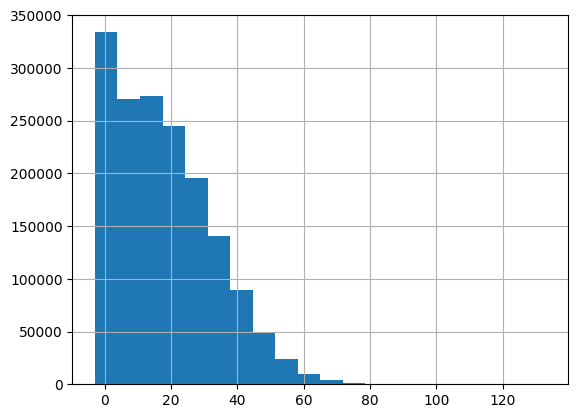

In [31]:
df_players_stats['fantasy_points'].hist(bins=20)

In [32]:
#rate of missing fantasy points
df_players_stats["fantasy_points"].isna().mean()

np.float64(0.0007436391099268195)

Right skewness observed --> Apply log & Yeo-Johnson transformation to reduce skewness. Use it later for the Linear Regression model and compare its output without the transformation.

In [41]:
s  = df_players_stats['fantasy_points'].dropna()
print("skew original:", s.skew())

from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
s_yj = pd.Series(pt.fit_transform(s.values.reshape(-1,1)).flatten(), index=s.index)
print("skew yeo-johnson:", s_yj.skew())

if (s > -1).all():
  s_log = np.log1p(s)
  print("skew log transform:", s_log.skew())
else:
  print("lopg1p not valid beacuse some fantasy points have negative values.")

skew original: 0.7571950422256863
skew yeo-johnson: -0.18897116423341334
lopg1p not valid beacuse some fantasy points have negative values.


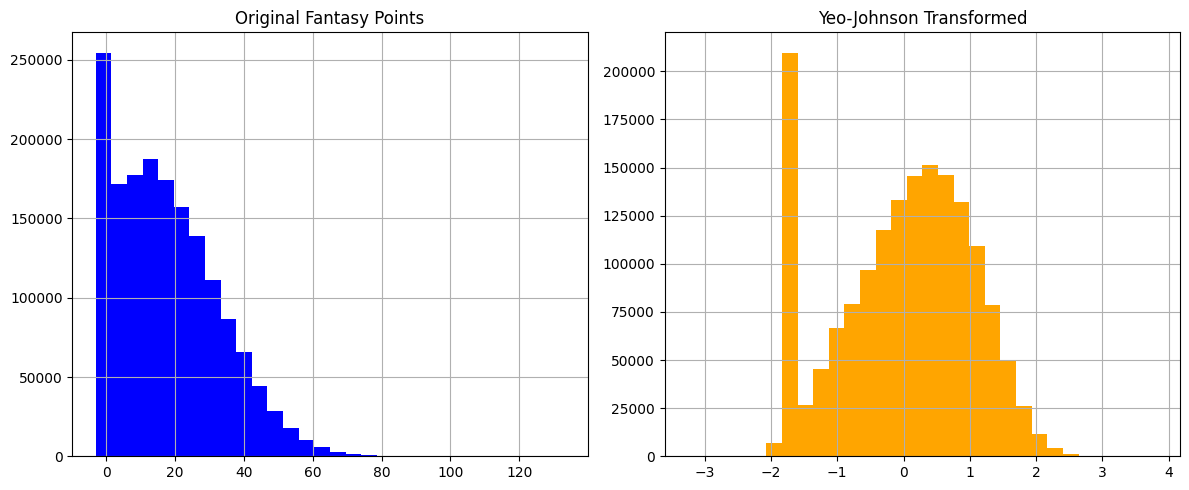

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

s.hist(bins=30, ax=axes[0], color="blue")
axes[0].set_title("Original Fantasy Points")

s_yj.hist(bins=30, ax=axes[1], color="orange")
axes[1].set_title("Yeo-Johnson Transformed")

plt.tight_layout()
plt.show()

Plot heatmap to see the correlation between features

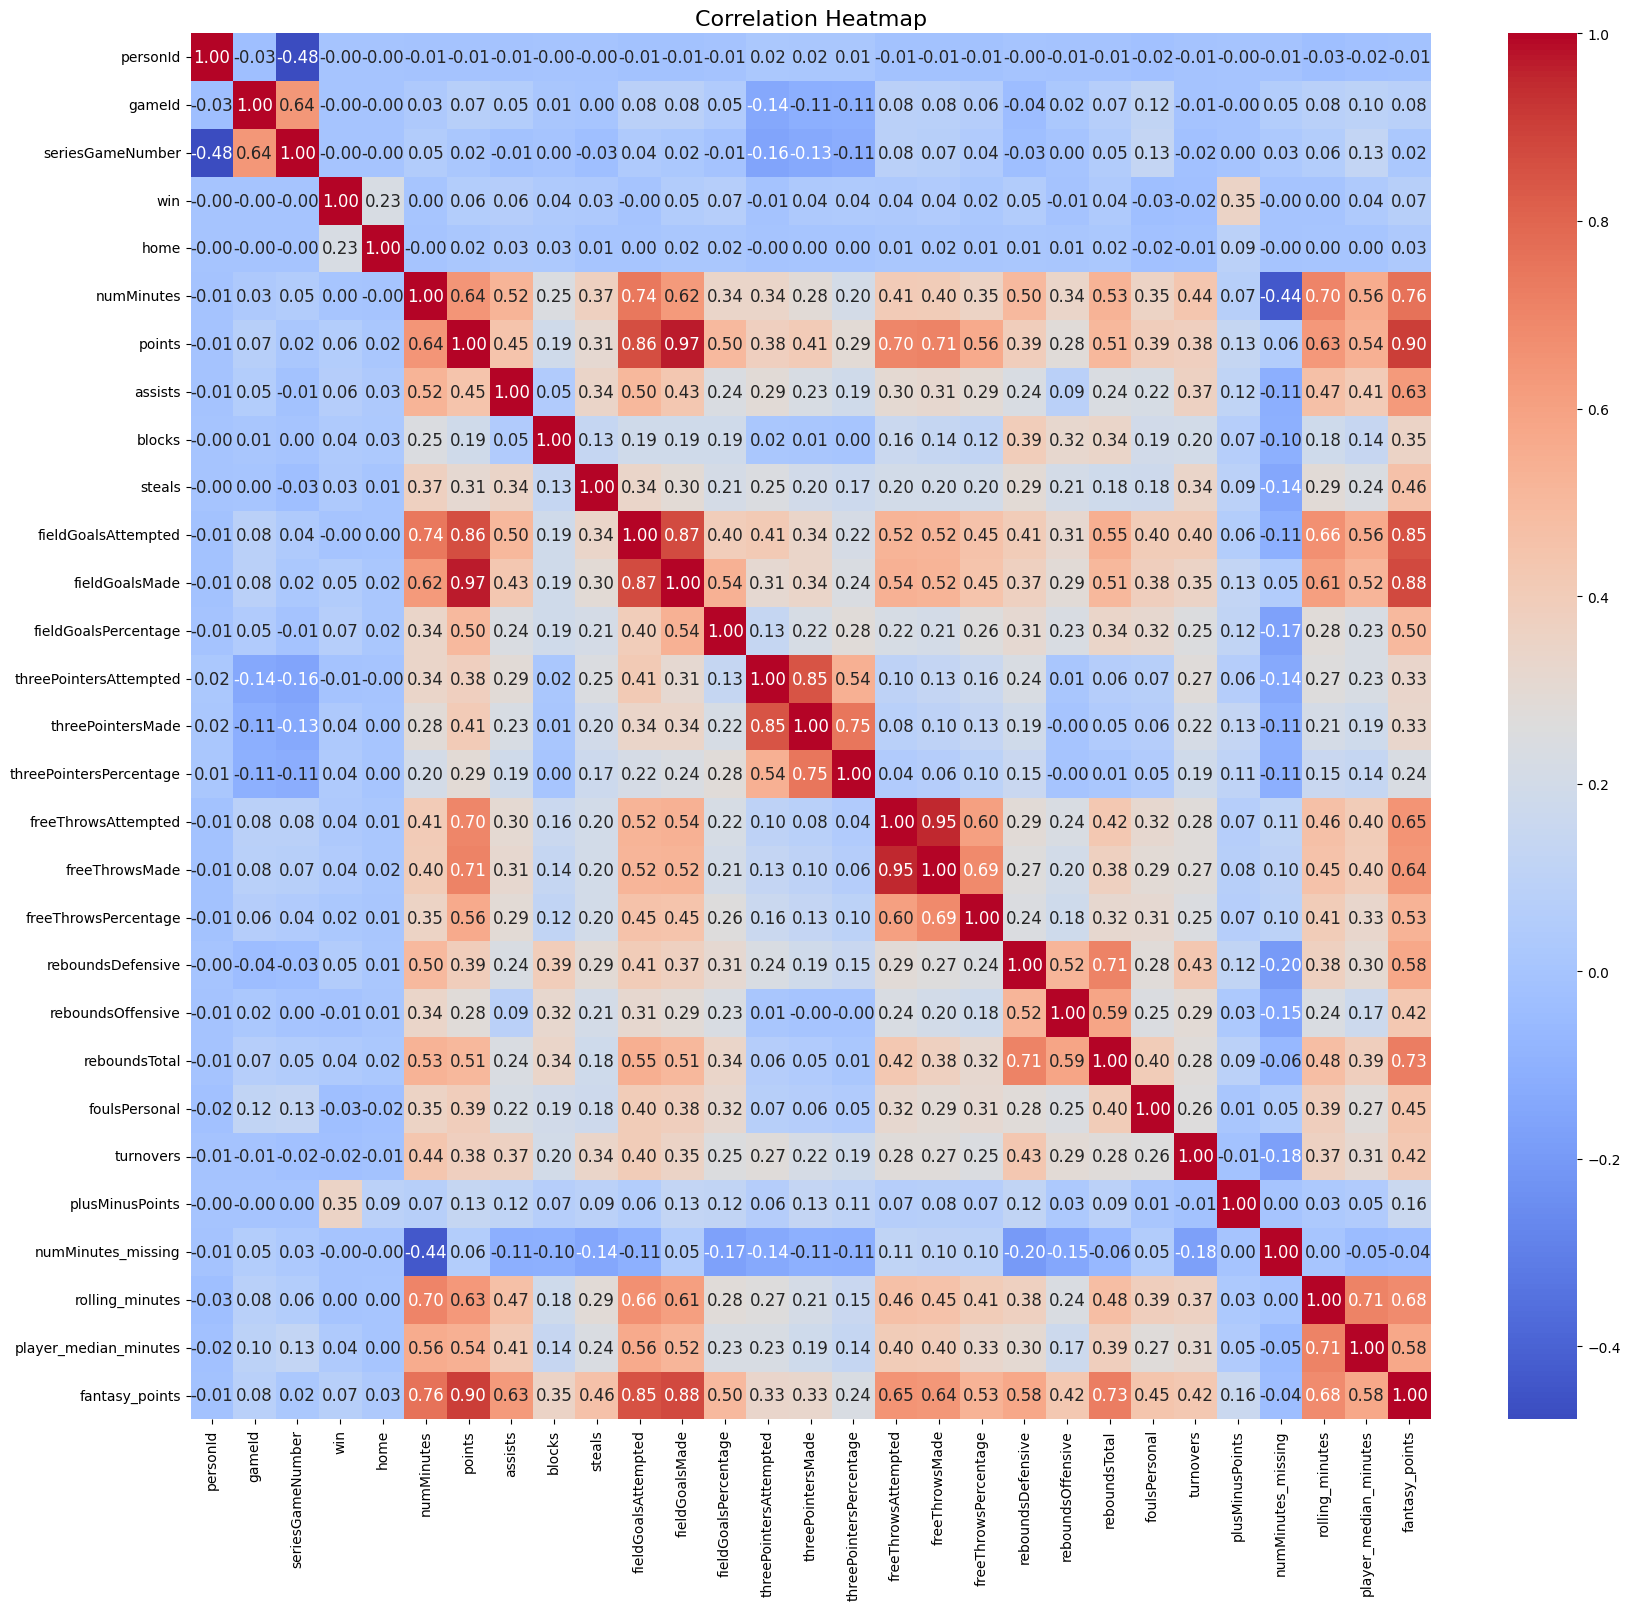

In [63]:
stats_df = df_players_stats.select_dtypes(include=[np.number])
corr_matrix = stats_df.corr()

# Plot heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True, annot_kws={"size": 12})
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

In [65]:
game_type = ["Regular Season", "Playoffs"]

df_players_stats = df_players_stats[df_players_stats["gameType"].isin(game_type)]
df_players_stats["gameType"].value_counts()

gameType
Regular Season    1470402
Playoffs            99840
Name: count, dtype: int64

In [68]:
#create playoff_flag
df_players_stats["is_playoff"] = (df_players_stats["gameType"] == "Playoffs").astype(int)

df_players_stats[["gameType", "is_playoff"]].sample(5)

,gameType,is_playoff
1526691,Regular Season,0
955359,Regular Season,0
1260479,Regular Season,0
334904,Playoffs,1
1332566,Regular Season,0


In [70]:
#sort by player and date
players_stats = df_players_stats.sort_values(['personId', 'gameDateTimeEst'])


In [71]:
#export regular_season dataframe
players_stats.to_csv('../data/modified/player_stats.csv', index=False)